# Face Landmarks Detection with MediaPipe Tasks (Local)

Esta versión del notebook está refactorizada para correr en una máquina local en lugar de Google Colab:\n
- Se evitaron magics y APIs específicas de Colab (como `google.colab.patches` y `!pip`).\n
- Se usa `matplotlib` para visualización dentro del notebook.\n
- Se añade una celda opcional para instalar dependencias localmente usando `python -m pip` si el usuario lo desea.

## Dependencias
Si no tienes las bibliotecas necesarias instaladas, ejecuta la celda siguiente (opcional). Recomiendo usar un entorno virtual: `python -m venv .venv && source .venv/bin/activate`.

In [1]:
!python -m pip install mediapipe matplotlib opencv-python

## Descargar el modelo y una imagen de ejemplo (si no existen)
Las descargas se hacen con código Python para no depender de `wget`.

In [9]:
import os
from urllib.request import urlretrieve
MODEL_NAME = 'face_landmarker_v2_with_blendshapes.task'
MODEL_URL = 'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task'
IMAGE_NAME = 'image.png'
IMAGE_URL = 'https://storage.googleapis.com/mediapipe-assets/business-person.png'
if not os.path.exists(MODEL_NAME):
    print('Descargando modelo...')
    urlretrieve(MODEL_URL, MODEL_NAME)
else:
    print('Modelo ya existe:', MODEL_NAME)
if not os.path.exists(IMAGE_NAME):
    print('Descargando imagen de ejemplo...')
    urlretrieve(IMAGE_URL, IMAGE_NAME)
else:
    print('Imagen ya existe:', IMAGE_NAME)

Modelo ya existe: face_landmarker_v2_with_blendshapes.task
Imagen ya existe: image.png


In [10]:
# Utilidades de visualización y helpers (usa matplotlib en local)
import mediapipe as mp
from mediapipe.framework.formats import landmark_pb2
import numpy as np
import matplotlib.pyplot as plt
import cv2

def draw_landmarks_on_image(rgb_image, detection_result):
    annotated_image = np.copy(rgb_image)
    face_landmarks_list = detection_result.face_landmarks
    for face_landmarks in face_landmarks_list:
        face_landmarks_proto = landmark_pb2.NormalizedLandmarkList()
        face_landmarks_proto.landmark.extend([landmark_pb2.NormalizedLandmark(x=l.x, y=l.y, z=l.z) for l in face_landmarks])
        mp.solutions.drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=face_landmarks_proto,
            connections=mp.solutions.face_mesh.FACEMESH_TESSELATION,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp.solutions.drawing_styles.get_default_face_mesh_tesselation_style())
        mp.solutions.drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=face_landmarks_proto,
            connections=mp.solutions.face_mesh.FACEMESH_CONTOURS,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp.solutions.drawing_styles.get_default_face_mesh_contours_style())
        mp.solutions.drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=face_landmarks_proto,
            connections=mp.solutions.face_mesh.FACEMESH_IRISES,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp.solutions.drawing_styles.get_default_face_mesh_iris_connections_style())
    return annotated_image

def plot_face_blendshapes_bar_graph(face_blendshapes):
    names = [c.category_name for c in face_blendshapes]
    scores = [c.score for c in face_blendshapes]
    ranks = range(len(names))
    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(ranks, scores)
    ax.set_yticks(ranks)
    ax.set_yticklabels(names)
    ax.invert_yaxis()
    for score, patch in zip(scores, bars):
        plt.text(patch.get_x() + patch.get_width(), patch.get_y(), f'{score:.4f}')
    plt.xlabel('Score')
    plt.title('Face Blendshapes')
    plt.tight_layout()
    plt.show()

In [11]:
# Mostrar blendshapes y matrix de transformación
if hasattr(detection_result, 'face_blendshapes') and detection_result.face_blendshapes:
    plot_face_blendshapes_bar_graph(detection_result.face_blendshapes[0])

print('Facial transformation matrices:')
print(getattr(detection_result, 'facial_transformation_matrixes', None))

NameError: name 'detection_result' is not defined

I0000 00:00:1765813333.334206    5916 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1765813333.337491    6120 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.7), renderer: Mesa Intel(R) Graphics (ADL GT2)
W0000 00:00:1765813333.353494    5916 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1765813333.365406    6121 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1765813333.378297    6130 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


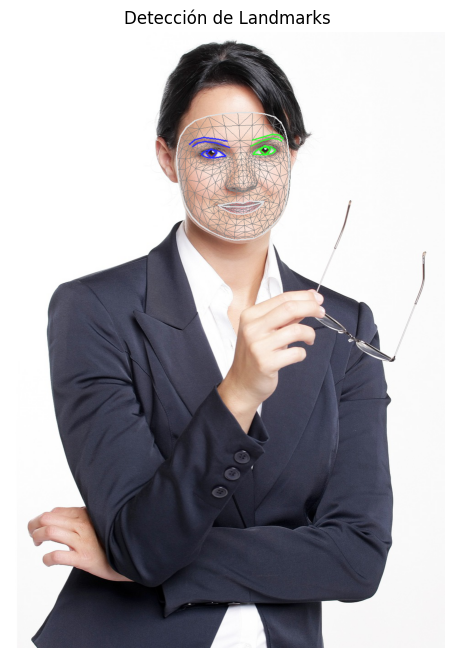

In [12]:
# Correr la inferencia en la imagen de ejemplo
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

model_path = 'face_landmarker_v2_with_blendshapes.task'
if not os.path.exists(model_path):
    raise FileNotFoundError(f'Model file not found: {model_path} - ejecuto la celda de descarga antes de esta')

base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.FaceLandmarkerOptions(base_options=base_options, output_face_blendshapes=True, output_facial_transformation_matrixes=True, num_faces=1)
detector = vision.FaceLandmarker.create_from_options(options)

image = mp.Image.create_from_file('image.png')
detection_result = detector.detect(image)

annotated = draw_landmarks_on_image(image.numpy_view(), detection_result)
# Mostrar con matplotlib (convertir a BGR si es necesario)
plt.figure(figsize=(8, 8))
plt.imshow(annotated)
plt.axis('off')
plt.title('Detección de Landmarks')
plt.show()

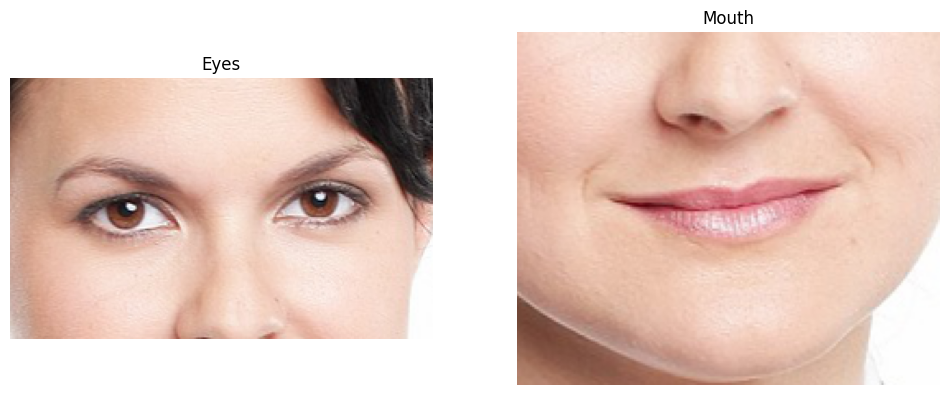

In [13]:
# Extraer y plotear landmarks de ojos y boca (recorte)
import matplotlib.pyplot as plt
import cv2

def get_unique_landmark_indices(connections_set):
    indices = set()
    for connection in connections_set:
        indices.add(connection[0])
        indices.add(connection[1])
    return indices

lips_indices = get_unique_landmark_indices(mp.solutions.face_mesh.FACEMESH_LIPS)
left_eye_indices = get_unique_landmark_indices(mp.solutions.face_mesh.FACEMESH_LEFT_EYE)
right_eye_indices = get_unique_landmark_indices(mp.solutions.face_mesh.FACEMESH_RIGHT_EYE)

if 'detection_result' not in locals():
    print('Ejecuta antes la celda de inferencia.')
else:
    face_landmarks = detection_result.face_landmarks[0]
    img_bgr = cv2.imread('image.png')
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    def bbox_from_indices(indices, all_landmarks, padding=0.05):
        xs, ys = [], []
        for idx in indices:
            lm = all_landmarks[idx]
            xs.append(int(lm.x * w))
            ys.append(int(lm.y * h))
        if not xs or not ys:
            return None
        min_x, max_x = max(0, min(xs) - int(w*padding)), min(w, max(xs) + int(w*padding))
        min_y, max_y = max(0, min(ys) - int(h*padding)), min(h, max(ys) + int(h*padding))
        return (min_x, min_y, max_x, max_y)
    eyes_idx = left_eye_indices.union(right_eye_indices)
    eyes_box = bbox_from_indices(eyes_idx, face_landmarks)
    lips_box = bbox_from_indices(lips_indices, face_landmarks)
    crops = []
    if eyes_box:
        x0,y0,x1,y1 = eyes_box
        crops.append(('Eyes', img_rgb[y0:y1,x0:x1]))
    if lips_box:
        x0,y0,x1,y1 = lips_box
        crops.append(('Mouth', img_rgb[y0:y1,x0:x1]))
    if crops:
        fig = plt.figure(figsize=(6*len(crops),6))
        for i,(title,cimg) in enumerate(crops,1):
            ax = fig.add_subplot(1,len(crops),i)
            ax.imshow(cimg)
            ax.set_title(title)
            ax.axis('off')
        plt.show()
    else:
        print('No se pudo recortar ninguna región.')

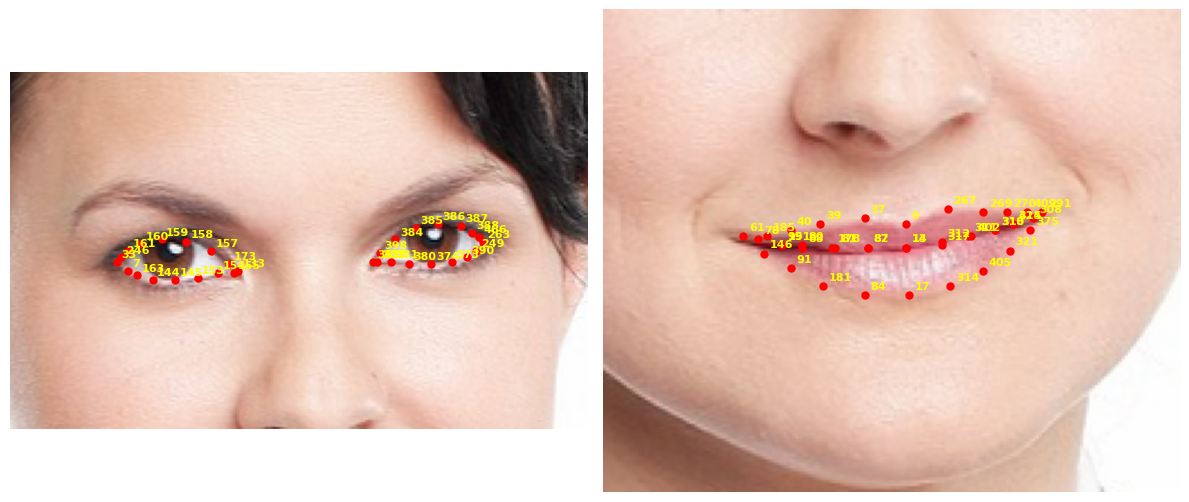

In [14]:
# Visualizar landmarks enumerados en los recortes de ojos y boca
fig = plt.figure(figsize=(6*len(crops), 6))

crop_regions = [('Eyes', eyes_idx, eyes_box), ('Mouth', lips_indices, lips_box)]

for plot_idx, (region_name, landmark_indices, bbox) in enumerate(crop_regions, 1):
    if bbox is None:
        continue
    
    x0, y0, x1, y1 = bbox
    crop_img = img_rgb[y0:y1, x0:x1]
    
    ax = fig.add_subplot(1, len([c for _, _, c in crop_regions if c is not None]), plot_idx)
    ax.imshow(crop_img)
    
    # Plotear landmarks enumerados dentro del recorte
    for idx in sorted(landmark_indices):
        landmark = face_landmarks[idx]
        # Convertir coordenadas normalizadas a píxeles de la imagen original
        px = int(landmark.x * w)
        py = int(landmark.y * h)
        
        # Convertir a coordenadas relativas del recorte
        crop_x = px - x0
        crop_y = py - y0
        
        # Verificar que el landmark está dentro del recorte
        if 0 <= crop_x < crop_img.shape[1] and 0 <= crop_y < crop_img.shape[0]:
            ax.plot(crop_x, crop_y, 'ro', markersize=5)
            ax.text(crop_x + 2, crop_y - 2, str(idx), color='yellow', fontsize=8, fontweight='bold')
    
    # ax.set_title(f'{region_name} (Landmarks: {sorted(landmark_indices)})')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [16]:
# Detectar landmarks en tiempo real desde webcam
import cv2
import numpy as np
from mediapipe.framework.formats import landmark_pb2

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: No se puede acceder a la webcam.")
else:
    print("Webcam iniciada. Presiona 'q' para salir.")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Error al leer el frame.")
            break
        
        # Convertir BGR a RGB para MediaPipe
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Convertir a MP Image
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        
        # Detectar landmarks
        detection_result = detector.detect(mp_image)
        
        # Dibujar landmarks en el frame
        if detection_result.face_landmarks:
            annotated_frame = np.copy(rgb_frame)
            
            for face_landmarks in detection_result.face_landmarks:
                face_landmarks_proto = landmark_pb2.NormalizedLandmarkList()
                face_landmarks_proto.landmark.extend([
                    landmark_pb2.NormalizedLandmark(x=l.x, y=l.y, z=l.z) 
                    for l in face_landmarks
                ])
                
                mp.solutions.drawing_utils.draw_landmarks(
                    image=annotated_frame,
                    landmark_list=face_landmarks_proto,
                    connections=mp.solutions.face_mesh.FACEMESH_TESSELATION,
                    landmark_drawing_spec=None,
                    connection_drawing_spec=mp.solutions.drawing_styles.get_default_face_mesh_tesselation_style())
                mp.solutions.drawing_utils.draw_landmarks(
                    image=annotated_frame,
                    landmark_list=face_landmarks_proto,
                    connections=mp.solutions.face_mesh.FACEMESH_CONTOURS,
                    landmark_drawing_spec=None,
                    connection_drawing_spec=mp.solutions.drawing_styles.get_default_face_mesh_contours_style())
                mp.solutions.drawing_utils.draw_landmarks(
                    image=annotated_frame,
                    landmark_list=face_landmarks_proto,
                    connections=mp.solutions.face_mesh.FACEMESH_IRISES,
                    landmark_drawing_spec=None,
                    connection_drawing_spec=mp.solutions.drawing_styles.get_default_face_mesh_iris_connections_style())
            
            # Convertir de RGB a BGR para mostrar con OpenCV
            display_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_RGB2BGR)
        else:
            display_frame = frame
        
        # Mostrar frame
        cv2.imshow('Face Landmarks - Webcam', display_frame)
        
        # Presionar 'q' para salir
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()
    print("Webcam cerrada.")

Webcam iniciada. Presiona 'q' para salir.


qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/antares/anaconda3/envs/tesis/lib/python3.12/site-packages/cv2/qt/plugins"


Webcam cerrada.
